# 03: Continuous Variables and Moderation

DiD is not limited to binary outcomes or binary controls. The
simplest treatment variable is binary, but outcomes, controls,
moderators, and even treatment intensity can be continuous.

With continuous exposure, `exposure:post` is a slope-change
parameter: it measures how much more the outcome changes after
rollout for one additional unit of exposure. A causal reading
requires a stronger version of parallel trends: absent the
rollout, the pre/post change in the outcome would not have
systematically varied with exposure intensity after accounting
for the model's controls.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

from checks import check_close, check_columns, check_same_estimate, check_sign
from did_utils import (
    did_2x2_table,
    manual_did,
    predicted_values_2x2,
    plot_group_trends,
    plot_did_counterfactual,
    make_event_dummies,
    extract_event_study_results,
    plot_event_study,
)


plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")


Running outside JupyterLite; assuming packages are already installed.


In [2]:
df = pd.read_csv(DATA_DIR / "platform_exposure_panel.csv")
df["exposure_group"] = pd.qcut(df["exposure"], 3, labels=["Low exposure", "Medium exposure", "High exposure"])
df.head()


,market_id,quarter,post,exposure,retention_rate,marketing_spend,competitor_price,digital_maturity,revenue_per_user,exposure_group
0,M01,1,0,3.87,56.97,43.58,20.00,0.356,38.77,Medium exposure
1,M01,2,0,3.87,55.86,58.77,19.06,0.356,36.14,Medium exposure
2,M01,3,0,3.87,56.55,57.71,18.67,0.356,38.51,Medium exposure
3,M01,4,0,3.87,55.51,55.23,17.95,0.356,39.63,Medium exposure
4,M01,5,1,3.87,60.71,56.06,17.71,0.356,42.14,Medium exposure


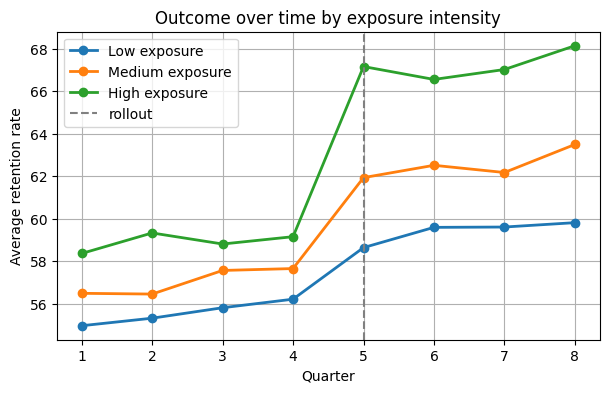

In [3]:
trend = (
    df.groupby(["quarter", "exposure_group"], observed=True)["retention_rate"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots()
for group, part in trend.groupby("exposure_group", observed=True):
    ax.plot(part["quarter"], part["retention_rate"], marker="o", linewidth=2, label=group)
ax.axvline(5, color="gray", linestyle="--", label="rollout")
ax.set_xlabel("Quarter")
ax.set_ylabel("Average retention rate")
ax.set_title("Outcome over time by exposure intensity")
ax.legend()
plt.show()


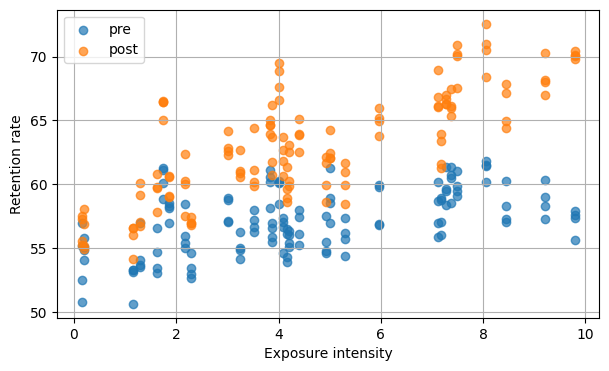

In [4]:
fig, ax = plt.subplots()
for post_value, part in df.groupby("post"):
    label = "post" if post_value == 1 else "pre"
    ax.scatter(part["exposure"], part["retention_rate"], alpha=0.7, label=label)
ax.set_xlabel("Exposure intensity")
ax.set_ylabel("Retention rate")
ax.legend()
plt.show()


In [5]:
model_exposure = smf.ols("retention_rate ~ exposure * post", data=df).fit()
model_controls = smf.ols(
    "retention_rate ~ exposure * post + marketing_spend + competitor_price",
    data=df,
).fit()

pd.DataFrame(
    {
        "exposure_only": model_exposure.params,
        "with_controls": model_controls.params,
    }
)


,exposure_only,with_controls
Intercept,54.870331,68.137603
competitor_price,NaN,-0.717623
exposure,0.501403,0.460172
exposure:post,0.772768,0.829309
marketing_spend,NaN,-0.003189
post,2.323390,2.069813


Because this is panel data, a closer DiD-style specification can
absorb market fixed effects and quarter fixed effects. The
time-invariant `exposure` main effect is absorbed by market
fixed effects, and the `post` main effect is absorbed by quarter
fixed effects; the coefficient on `exposure:post` remains
identified because it varies across both markets and time.


In [6]:
model_exposure_fe = smf.ols(
    "retention_rate ~ exposure:post + C(market_id) + C(quarter)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["market_id"]})

pd.Series(
    {
        "FE exposure:post estimate": model_exposure_fe.params["exposure:post"],
        "clustered SE": model_exposure_fe.bse["exposure:post"],
    }
)


FE exposure:post estimate    0.772768
clustered SE                 0.119164
dtype: float64

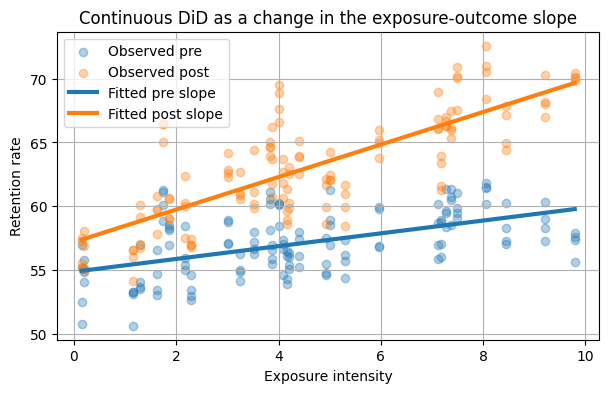

In [7]:
x_grid = np.linspace(df["exposure"].min(), df["exposure"].max(), 100)
line_df = pd.concat(
    [
        pd.DataFrame({"exposure": x_grid, "post": 0}),
        pd.DataFrame({"exposure": x_grid, "post": 1}),
    ],
    ignore_index=True,
)
line_df["predicted_retention"] = model_exposure.predict(line_df)

fig, ax = plt.subplots()
for post_value, part in df.groupby("post"):
    label = "Observed post" if post_value == 1 else "Observed pre"
    ax.scatter(part["exposure"], part["retention_rate"], alpha=0.35, label=label)
for post_value, part in line_df.groupby("post"):
    label = "Fitted post slope" if post_value == 1 else "Fitted pre slope"
    ax.plot(part["exposure"], part["predicted_retention"], linewidth=3, label=label)
ax.set_xlabel("Exposure intensity")
ax.set_ylabel("Retention rate")
ax.set_title("Continuous DiD as a change in the exposure-outcome slope")
ax.legend()
plt.show()


## Moderation

A moderator asks whether the treatment effect is different for
different kinds of units. Here, `digital_maturity` measures how
ready a market is to benefit from the checkout feature.


In [8]:
df["digital_maturity_c"] = df["digital_maturity"] - df["digital_maturity"].mean()

model_moderation = smf.ols(
    "retention_rate ~ exposure * post * digital_maturity_c + marketing_spend + competitor_price",
    data=df,
).fit()

model_moderation.params[[
    "exposure:post",
    "exposure:post:digital_maturity_c",
]]


exposure:post                       0.850032
exposure:post:digital_maturity_c    0.345089
dtype: float64

In [9]:
beta_base = model_moderation.params["exposure:post"]
beta_mod = model_moderation.params["exposure:post:digital_maturity_c"]
maturity_values = [-1, 0, 1]

pd.DataFrame(
    {
        "digital_maturity_c": maturity_values,
        "estimated_effect_per_exposure_unit": [beta_base + beta_mod * z for z in maturity_values],
    }
)


,digital_maturity_c,estimated_effect_per_exposure_unit
0,-1,0.504943
1,0,0.850032
2,1,1.195121


Takeaway: a continuous `exposure:post` coefficient describes the
extra post-period change associated with one additional unit of
exposure, conditional on the model. A triple interaction lets
that slope vary by a moderator.
